In [29]:
fig_num = 7 # change this to the figure number
analysis_name = "finger_bci" # change this to the subfolder it should save to

from c3po.analysis.analysis import figure_directory
from pathlib import Path
fig_dir = Path(figure_directory) / f"Fig{fig_num}" /analysis_name
fig_dir.mkdir(parents=True, exist_ok=True)
fig_dir

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
import pandas as pd
from pathlib import Path
file_path = "/home/sambray/Documents/c3po/tutorial/c3po_dandi_candidate_datasets_v2.csv"
dataset_df = pd.read_csv(file_path)

dandiset_id = 147

dataset_df = dataset_df[dataset_df['dandiset_id'] == dandiset_id]

dandiset_id = f"{dandiset_id:06d}"
dandi_path = dataset_df['dandi_path'].values[0]
model_dir = Path(f"/stelmo/sam/c3po_dandi_training_v2/{dandiset_id}")

In [3]:
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # Disable GPU usage for this example

from pathlib import Path
from dandi.dandiapi import DandiAPIClient
from dandi.consts import known_instances
import fsspec
from fsspec.implementations.cached import CachingFileSystem
import h5py
import pynwb

def get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi"):
    tmp_dir = "dandi_cache"  # Local folder for cache
    Path(tmp_dir).mkdir(exist_ok=True)  # Create the cache folder if it doesn't exist

    # get the s3 url from Dandi
    with DandiAPIClient(
        dandi_instance=known_instances[dandi_instance],
    ) as client:
        asset = client.get_dandiset(dandiset_id).get_asset_by_path(dandi_path)
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

    # stream the file from s3
    # first, create a virtual filesystem based on the http protocol
    fs = fsspec.filesystem("http")

    # create a cache to save downloaded data to disk (optional)
    fsspec_file = CachingFileSystem(
        fs=fs,
        cache_storage=tmp_dir,  # Local folder for cache
    )

    # Open and return the file
    fs_file = fsspec_file.open(s3_url, "rb")
    io = pynwb.NWBHDF5IO(file=h5py.File(fs_file))
    nwbfile = io.read()
    return io, nwbfile

In [4]:
nwbfile = get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi")[1]

In [5]:
from c3po.analysis.analysis import C3poAnalysis
import numpy as np
analysis = C3poAnalysis(model_dir=model_dir)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

In [6]:
nwbfile

root pynwb.file.NWBFile at 0x139728805597184
Fields:
  devices: {
    NSP1 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    PPC <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  experiment_description: Intracortical recordings during a brain-computer interface finger movement task
  experimenter: ['Tyson Aflalo' 'Carey Zhang']
  file_create_date: [datetime.datetime(2022, 2, 11, 9, 11, 12, 614907, tzinfo=tzoffset(None, -28800))]
  identifier: sub-P1_ses-20180910T102421
  institution: California Institute of Technology
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: Andersen Lab
  session_description: individual-finger press, main task
  session_id: 2018-09-10
  session_start_time: 2018-09-10 10:24:21-07:00
  subject: subject pynwb.file.Subject at 0x139728805606304
Fields:
  description: tetraplegic woman
  sex: F
  species: Human
  subject_id: P1

  timestamps_reference_time: 2018-09-10 10:24:21-07:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>
  units: units <class 'pynwb.misc.Units'>

In [8]:
obj_id = dataset_df['event_object_id'].values[0]
event_df = nwbfile.objects[obj_id].to_dataframe()
event_df#[:30]

,Run,TrialNumber,start_time,stop_time,finger,finger_pred,cue_location
id,,,,,,,
0,0,1,2290.094389,2293.094389,X,I,5
1,0,2,2293.223389,2296.223389,I,R,9
2,0,3,2296.353556,2299.353556,T,T,6
3,0,4,2299.453589,2302.453589,M,R,4
4,0,5,2302.543589,2305.543589,R,R,10
...,...,...,...,...,...,...,...
379,7,44,3886.139045,3889.139045,T,T,10
380,7,45,3889.239212,3892.239212,I,I,12
381,7,46,3892.339245,3895.339245,R,R,8


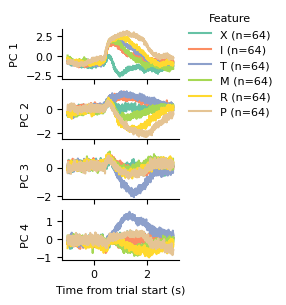

In [30]:
mark = "start_time"
feature = "finger"
window = (-1,3)

# fig, ax = plt.subplots(nrows = 8, sharex=True, figsize=(4,8))

fig, ax = plt.subplots(nrows = 4, sharex=True, figsize=(1.5,3))
feature_val_list = event_df[feature].unique()
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for i_feat, feature_val in enumerate(feature_val_list):
    df = event_df[event_df[feature] == feature_val]
    result = analysis.alligned_response(df[mark].values, window, pca=True)
    mid = np.mean(result, axis=0)
    low = np.percentile(result, 25, axis=0)
    high = np.percentile(result, 75, axis=0)
    if isinstance(feature_val, str):
        color = i_feat / len(feature_val_list)
        color = plt.cm.Set2(color)
    else:
        color = (feature_val - np.min(feature_val_list)) / (np.max(feature_val_list) - np.min(feature_val_list))
        color = plt.cm.viridis(color)
    t_plot = np.linspace(window[0], window[1], mid.shape[0])

    for i, a in enumerate(ax):
        # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
        label = f"{feature_val} (n={len(df)})"
        a.plot(t_plot, mid[:,i], color=color, label=label)
        a.set_ylabel(f"PC {i+1}")
        a.spines[['top', 'right']].set_visible(False)
ax[0].legend(title="Feature", bbox_to_anchor=(1.0, 1.5), loc='upper left', frameon=False)
ax[-1].set_xlabel("Time from trial start (s)")

fig.savefig(fig_dir / f"context_response.svg", bbox_inches='tight', dpi=300)

In [31]:
fig_dir

PosixPath('/home/sambray/Documents/c3po/Figures/Fig7/finger_bci')

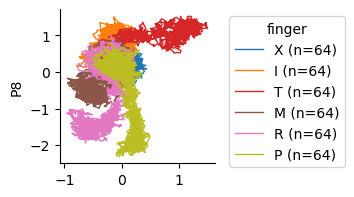

In [ ]:
pc_2d = (3,1)

mark = "start_time"
feature = "finger"
window = (-.1,2)

fig, ax = plt.subplots(nrows = 1, sharex=True, figsize=(2,2), )
feature_val_list = event_df[feature].unique()
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for i_feat, feature_val in enumerate(feature_val_list):
    df = event_df[event_df[feature] == feature_val]
    result = analysis.alligned_response(df[mark].values, window, pca=True)
    mid = np.mean(result, axis=0)
    low = np.percentile(result, 25, axis=0)
    high = np.percentile(result, 75, axis=0)
    if isinstance(feature_val, str):
        color = i_feat / len(feature_val_list)
        color = plt.cm.tab10(color)
    else:
        color = (feature_val - np.min(feature_val_list)) / (np.max(feature_val_list) - np.min(feature_val_list))
        color = plt.cm.viridis(color)
    t_plot = np.linspace(window[0], window[1], mid.shape[0])

        # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
    label = f"{feature_val} (n={len(df)})"
    mid = np.mean(result, axis=0)[:,pc_2d]
    ax.plot(mid[:,0], mid[:,1], color=color, label=label, lw=1)
ax.set_ylabel(f"P{i+1}")
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

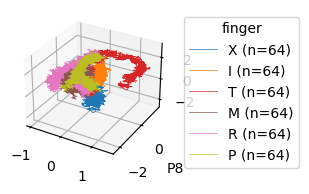

In [18]:
pc_3d = (3,1,0)

mark = "start_time"
feature = "finger"
window = (-.1,2)

# fig, ax = plt.subplots(nrows = 1, sharex=True, figsize=(2,2), projection='3d')
fig = plt.figure(figsize=(2,2))
ax = fig.add_subplot(111, projection='3d')
feature_val_list = event_df[feature].unique()
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for i_feat, feature_val in enumerate(feature_val_list):
    df = event_df[event_df[feature] == feature_val]
    result = analysis.alligned_response(df[mark].values, window, pca=True)
    mid = np.mean(result, axis=0)
    low = np.percentile(result, 25, axis=0)
    high = np.percentile(result, 75, axis=0)
    if isinstance(feature_val, str):
        color = i_feat / len(feature_val_list)
        color = plt.cm.tab10(color)
    else:
        color = (feature_val - np.min(feature_val_list)) / (np.max(feature_val_list) - np.min(feature_val_list))
        color = plt.cm.viridis(color)
    t_plot = np.linspace(window[0], window[1], mid.shape[0])

        # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
    label = f"{feature_val} (n={len(df)})"
    mid = np.mean(result, axis=0)[:,pc_3d]
    ax.plot(mid[:,0], mid[:,1],mid[:,2], color=color, label=label, lw=.5)
ax.set_ylabel(f"P{i+1}")
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

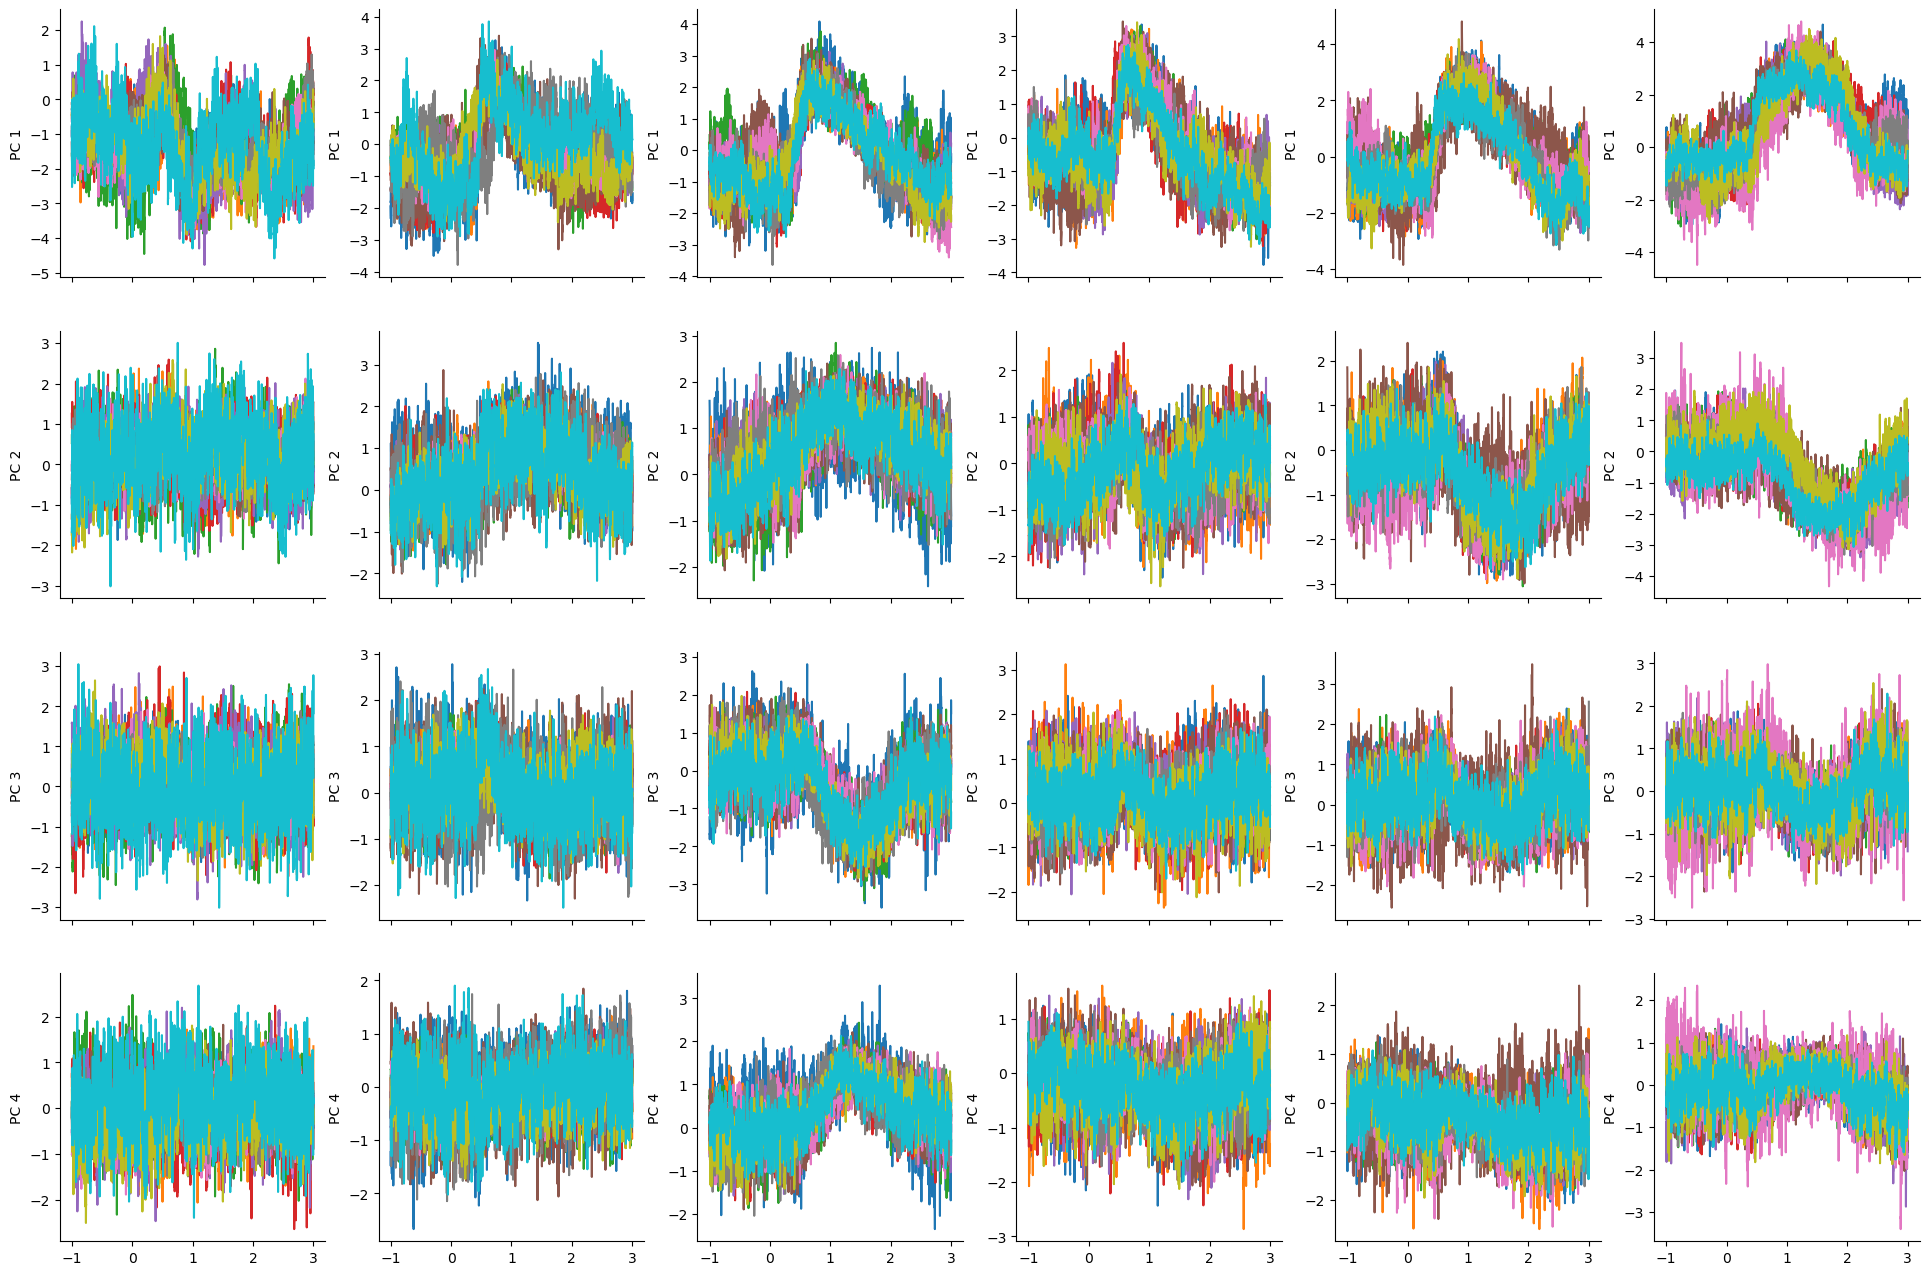

In [63]:
fingers = event_df['finger'].unique()
directions = event_df['cue_location'].unique()

n_pc = 4
fig, ax_list = plt.subplots(ncols = len(fingers),nrows = n_pc,
                            sharex=True,
                            figsize=(4*len(fingers),4*n_pc))

for i_finger, finger in enumerate(fingers):
    df = event_df[event_df['finger'] == finger]
    for i_dir, direction in enumerate(directions):
        df_dir = df[df['cue_location'] == direction]
        result = analysis.alligned_response(df_dir[mark].values, window, pca=True)
        mid = np.mean(result, axis=0)
        # low = np.percentile(result, 25, axis=0)
        # high = np.percentile(result, 75, axis=0)
        color = i_dir / len(directions)
        color = plt.cm.tab10(color)
        t_plot = np.linspace(window[0], window[1], mid.shape[0])
        for i_pc in range(n_pc):
            a = ax_list[i_pc,i_finger]
            # a.fill_between(t_plot, low[:,i_pc], high[:,i_pc], color=color, alpha=0.3)
            label = f"{direction} (n={len(df_dir)})"
            a.plot(t_plot, mid[:,i_pc], color=color, label=label)
            a.set_ylabel(f"PC {i_pc+1}")
            a.spines[['top', 'right']].set_visible(False)

In [22]:
dataset_df

,dandiset_id,dandi_path,publication_source,behavioral_or_experimental_feature_to_compare,number_of_units,brain_regions_of_recording,why_chosen,event_object_path,event_object_id,event_feature_name
19,689,sub-H19/sub-H19_ses-H19-2019-10-31-17-44-38-Di...,"Li et al., Nature (2022), https://doi.org/10.1...",Pavlovian discrimination trial type and valenc...,64,Amygdala (asset electrode location unspecified),Single-system aversive and appetitive learning...,/intervals/trials,b2a7b630-c4b5-4592-a6f9-720a0b3ec528,start_time


In [54]:
dataset_df.publication_source.values[0]

'https://doi.org/10.7554/eLife.74478'

In [59]:
import yaml
yaml_path = model_dir / "metrics.yaml"
metrics = yaml.safe_load(open(yaml_path, "r"))
metrics

{'dimensions': 16,
 'mua_rate': 769.8736763524187,
 'n_units': 100,
 'training_time': 644.4077506065369}